In [14]:
import numpy as np
import pandas as pd
import pickle as pk
from brian2 import *
import os, sys, shutil
from random import randint
import scipy.interpolate as itp
from itertools import product, chain, starmap
from multiprocessing import Pool

sys.path.insert(0, '../../scripts_analysis')
sys.path.insert(0, '../../model_steps')
from peaks import *
from analysis import *

## MCell analysis

In [15]:
setupLoc = '../../model_mcell'
resultPath = "../../data/control_eachCa/"
dataPath = "../../data/control/"

tempdirs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)

for i,d in enumerate(tempdirs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

In [ ]:
setupLoc = '/home/nishant/lab/MFB/mcell'
setup = np.genfromtxt(os.path.join(setupLoc, 'controls.dat'), usecols=(1,2,3,4,6), dtype='int')

dirs = []
for s in setup:
    naz   = s[2]
    dvdcc = s[1]
    rrp   = s[3]
    nvdcc = s[0]
    done  = s[4]

    nap = 10
    ISI = [20]
    
    if not done:
        for isi in ISI:
            f = f"nVDCC_{nvdcc}_dVDCC_{dvdcc}_nAZ_{naz}_RRP_{rrp}_ISI_{isi}_nAP_{nap}"
            dirs.append(f)
            
dirs = np.array(dirs)
print(dirs)

### Averaging Calcium Data

In [ ]:
for d in tq(tempdirs[:], desc=f'AVG (Ca):'):
    step, nAZ = 5, int(getSimInfo(d, 'nAZ'))

    f, ax = plt.subplots(nAZ,figsize=(25,5*nAZ), sharex=True)
    f.subplots_adjust(wspace=0.0, hspace=0.0)
    
    desc = '_'.join([a for a in re.findall(r'\d+', d)[:-2]])
    for naz in tq(range(1,nAZ+1), desc=desc):
        fname = 'ca_AZ_'+str(naz)+'.dat'
        t0 = time()
        data = avg_dat(dataPath, resultPath, d, fname, cores=40, ret=True)
        t1 = time()
        # 0th index containing timepoints
        CaData = [data[0,range(0,len(data[0])-step-1,step)]]
        
        #for i in range(1,data.shape[0]):
        sCa = np.sum(data[[1,naz+1]], axis=0)
        aCa = np.sum(data[1:nAZ+2], axis=0)
        
        CaData.append(getConc([data[0],sCa], step=step))
        CaData.append(getConc([data[0],aCa], step=step))
        
        CaData = np.array(CaData)
        t2 = time()
        #np.savetxt(os.path.join(resultPath,dir,f'CaConc_AZ_{naz}.dat'), CaData.T, delimiter='\t',
        #           fmt=['%.5f']+['%.5f']*(CaData.shape[0]-1), header='time\tself\tall')
        
        print(t1-t0, t2-t1)
        
        ax[naz-1].plot(CaData[0], CaData[2], color='g')
        ax[naz-1].plot(CaData[0], CaData[1], color='b', label=str(naz))
        ax[naz-1].set_xlim(0,0.210)
        ax[naz-1].legend()

    #except: print(f'Error in {dir}')

In [ ]:
fname = "ca.dat" 
jobInfo = list(product([dataPath], [resultPath], tempdirs[:], [fname]))

p = Pool(19)
p.starmap(avg_dat, jobInfo)
p.close()

### Generate AZ Calcium Concentration

In [ ]:
for dir in tempdirs[:]:
    step, nAZ = 5, int(getSimInfo(dir, 'nAZ'))

    f, ax = plt.subplots(nAZ,figsize=(25,5*nAZ), sharex=True)
    f.subplots_adjust(wspace=0.0, hspace=0.0)
    for naz in tq(range(1,nAZ+1)):
        
        ax[naz-1].plot(cdt[0], cdt[naz], color='r')
        
        fname = f'ca_AZ_{naz}.dat'
        data = np.genfromtxt(os.path.join(resultPath,dir,fname), unpack=True)

        # 0th index containing timepoints
        CaData = [data[0,range(0,len(data[0])-step-1,step)]]
        #print(CaData)
        
        #for i in range(1,data.shape[0]):
        sCa = np.sum(data[[1,naz+1]], axis=0)
        aCa = np.sum(data[1:nAZ+2], axis=0)
        
        CaData.append(getConc([data[0],sCa], step=step))
        CaData.append(getConc([data[0],aCa], step=step))
        
        CaData = np.array(CaData)
        
        #np.savetxt(os.path.join(resultPath,dir,f'CaConc_AZ_{naz}.dat'), CaData.T, delimiter='\t',
        #           fmt=['%.5f']+['%.5f']*(CaData.shape[0]-1), header='time\tself\tall')

        ax[naz-1].plot(CaData[0], CaData[2], color='g')
        ax[naz-1].plot(CaData[0], CaData[1], color='b', label=str(naz))
        ax[naz-1].set_xlim(0,0.210)
        ax[naz-1].legend()

## Plot MCell data

In [ ]:
#tempdirs = ['nVDCC_9_dVDCC_120_nAZ_7']
def plotCa(dir):
    CaGlobal = np.genfromtxt(os.path.join(resultPath,dir,'ca.dat'), unpack=True)
    CaAZ = np.genfromtxt(os.path.join(resultPath,dir,'CaConc.dat'), unpack=True)

    f, ax = plt.subplots(2, sharex=True, figsize=(15,8))
    f.subplots_adjust(hspace=0.0)

    ax[0].plot(CaGlobal[0]*1000, CaGlobal[1]*2.024e-4)
    ax[0].set_ylabel('Global Ca ($\mu$M)')
    ax[0].set_title(dir)

    for i in range(1,6):#len(CaAZ)+1):
        ax[1].plot(CaAZ[0]*1000+6*(i-1), CaAZ[i], label="AZ_{:d}".format(i))

    #ax[1].set_xlim(2, 3)
    ax[1].set_ylabel("$[Ca]$ ($\mu$M)")
    ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2)
    #ax[1].set_ylim(0,0.3)
    plt.show()
    
for dir in tempdirs[-1:]:
    plotCa(dir)

## AZ simulation in STEPS

In [4]:
from MFB_model import *
mdl, sim, r = get_MFB_model()

## Testing a single trail with STEPS

In [ ]:
CaFile = resultPath + 'nVDCC_2_dVAZ_60_nAZ_15_ISI_20_nAP_10/CaConc.dat'
CaData = np.genfromtxt(CaFile, unpack=True, skip_header=1)

T = np.arange(CaData[0][0], CaData[0][-1], 1e-5)
CaInterp = itp.interp1d(CaData[0], CaData[1])
CaInterpData = CaInterp(T)

resAZ, vesRel = simAZ(T, CaInterpData, sim, r)

nFig = 3
figure, ax = plt.subplots(nFig, figsize=(15, 4*nFig), sharex=True)
figure.subplots_adjust(hspace=0.1)
labelfontsize = 13

for mol in azMolName[:18]:
    i = azMolName.index(mol)
    ax[1].plot(T, resAZ[:,i], label=mol)
ax[1].set_ylabel('AZ states (num)', fontsize=labelfontsize)
ax[1].legend(bbox_to_anchor=(1, 1), loc='upper left', ncol=2)

vesRelSync  = np.sum(vesRel[:,:3], axis=1)
vesRelAsync = np.sum(vesRel[:,3:-1], axis=1)
vesRelSpont = vesRel[:,-1]
vesRelTot   = np.sum(vesRel, axis=1)

ax[2].plot(T, vesRelSync, label='sync')
ax[2].plot(T, vesRelAsync, label='async')
ax[2].plot(T, vesRelSpont, label='spont')
ax[2].plot(T, vesRelTot, label='total')
    
ax[2].set_ylabel('Vesicles released', fontsize=labelfontsize)
ax[2].legend()

peaks = detect_peaks(vesRelTot, edge='rising', show=False)
ax[2].plot(T[peaks], vesRelTot[peaks], '+', mfc=None, mec='r', mew=2, ms=15)
#print(T[peaks])

plt.show()

In [6]:
def runAZTrials(CaData, RRP):
    vesData = {}

    resAZ, vesRel = simAZ(CaData[0], CaData[1], sim, r, RRP=RRP)
    vesRelSync  = np.sum(vesRel[:,:3], axis=1)
    vesRelAsync = np.sum(vesRel[:,3:-2], axis=1)
    vesRelSpont  = vesRel[:,-1]

    # vesRelTot = np.sum(vesRel, axis=1)
    #print(vesRelSync, vesRelAsync, vesRelSpont)

    pksSync = detect_peaks(vesRelSync, edge='rising', show=False)
    pksAsync = detect_peaks(vesRelAsync, edge='rising', show=False)
    pksSpont = detect_peaks(vesRelSpont, edge='rising', show=False)

    vesData.update({'sync' : list(CaData[0,pksSync])})
    vesData.update({'async': list(CaData[0,pksAsync])})
    vesData.update({'spont': list(CaData[0,pksSpont])})

    return vesData, resAZ

In [ ]:
d = 'nVDCC_2_dVAZ_60_nAZ_15_ISI_20_nAP_10'
nAZ = 15
CaFile = os.path.join(resultPath, d, f'CaConc.dat')
temp = np.genfromtxt(CaFile, unpack=True, skip_header=1) # in uM
print(temp.shape)

sCaData = np.zeros((nAZ+1, temp.shape[1]))
sCaData[0] = temp[0]

for i in range(nAZ):
    sCaData[i+1] = np.sum(temp[4*i+2:4*i+4], axis=0)

sCaData[2][26:50].tolist()

In [7]:
def getVesRel(d, RRP, resultPath, trials=2000, pools=False):
    nAZ = int(getSimInfo(d, 'nAZ'))
    
    CaFile = os.path.join(resultPath, d, f'CaConc.dat')
    temp = np.genfromtxt(CaFile, unpack=True, skip_header=1) # in uM

    sCaData = np.zeros((nAZ+1, temp.shape[1]))
    sCaData[0] = temp[0]
    for i in range(nAZ):
        sCaData[i+1] = np.sum(temp[4*i+2:4*i+4], axis=0)

    if pools: p = Pool(pools)
    else: p = Pool()
        
    svesData = {}
    '''desc = 's_'+'_'.join([a for a in re.findall(r'\d+', d)[:-1]])
    for iCa in tq(range(1,nAZ+1), desc=desc):
        info = product([sCaData[(0,iCa),:]], [RRP]*trials)
        data = np.array(p.starmap(runAZTrials, info))
        
        vesSync  = [a['sync'] for a in data[:,0]]
        vesAsync = [a['async'] for a in data[:,0]]
        vesSpont = [a['spont'] for a in data[:,0]]
        svesData.update({f'AZ{iCa}': {'sync': vesSync, 'async':vesAsync, 'spont':vesSpont}})
        
        resAZ = data[:,1]
        AZstates = np.mean(resAZ, axis=0)
        fAZ = os.path.join(resultPath, d, f'sAZ_{iCa}.dat')
        AZdata = np.hstack((np.array([sCaData[0]]).T, AZstates))
        np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.4f']*18, delimiter="\t")
    '''
    desc = 'a_'+'_'.join([a for a in re.findall(r'\d+', d)[:-1]])
    for iCa in tq(range(1,nAZ+1), desc=desc):
        info = product([sCaData[(0,iCa),:]], [RRP]*trials)
        data = p.starmap(runAZTrials, info)
        
        vesSync  = [dd[0]['sync'] for dd in data]
        vesAsync  = [dd[0]['async'] for dd in data]
        vesSpont  = [dd[0]['spont'] for dd in data]
        svesData.update({f'AZ{iCa}': {'sync': vesSync, 'async':vesAsync, 'spont':vesSpont}})
        
        resAZ = np.array([dd[1] for dd in data])
        AZstates = np.mean(resAZ, axis=0)
        fAZ = os.path.join(resultPath, d, f'sAZ_{iCa}.dat')
        AZdata = np.hstack((np.array([sCaData[0]]).T, AZstates))
        np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.4f']*18, delimiter="\t")
    
    
    #print(vesData)
    p.close()
    return svesData
    
# getVesRel(tempdirs[0], RRP=RRP, resultPath=resultPath, trials=10)

In [ ]:
for d in tq(tempdirs[1:]):
    RRP = int(getSimInfo(d, 'RRP'))
    d = d.split('RRP')[0] + 'ISI' + d.split('ISI')[1]
    
    try:
        svesData = getVesRel(d, RRP=RRP, resultPath=resultPath, trials=20, pools=35)
        with open(os.path.join(resultPath, d, 'svesData.dat'), "wb") as outfile:
            pk.dump(svesData, outfile)

        # with open(os.path.join(resultPath, d, 'avesData.dat'), "wb") as outfile:
        #     pk.dump(svesData, outfile)
    except:
        print(f'Error in {d}')

## Get Vesicle Release Statistics

In [ ]:
for d in tq(tempdirs[1:]):
    RRP = int(getSimInfo(d, 'RRP'))
    d = d.split('RRP')[0] + 'ISI' + d.split('ISI')[1]

    # dir_path = os.path.join(resultPath, d)
    # files = [a for a in os.listdir(dir_path) if 'sAZ' in a]
    # print(d, files)


    # os.rename(os.path.join(dir_path, 'svesData.dat'), os.path.join(dir_path, f'svesData_RRP_{RRP}.dat'))
    # os.rename(os.path.join(dir_path, 'sresult.dat'), os.path.join(dir_path, f'sresult_RRP_{RRP}.dat'))

    # for file in files:
    #     new_file = file.replace('sAZ', f's_RRP_{RRP}_AZ')
    #     print(new_file)
    #     os.rename(os.path.join(dir_path, file), os.path.join(dir_path, new_file))


    # relStat(d, resultPath, inf='svesData.dat', resultf=f'sresult_RRP_{RRP}.dat', resample=100)
    # try:
        # relStat(d, resultPath, inf='svesData.dat', resultf='sresult.dat')
        # relStat(d, resultPath, inf='svesData.dat', resultf='sresult.dat')
    # except: print(f'Error in {dir}')

100%|██████████| 43/43 [00:00<00:00, 569.53it/s]

nVDCC_3_dVAZ_100_nAZ_29_ISI_20_nAP_10 ['sAZ_29.dat', 'sAZ_16.dat', 'sAZ_4.dat', 'sAZ_21.dat', 'sAZ_28.dat', 'sAZ_19.dat', 'sAZ_23.dat', 'sAZ_1.dat', 'sAZ_20.dat', 'sAZ_24.dat', 'sAZ_5.dat', 'sAZ_22.dat', 'sAZ_9.dat', 'sAZ_3.dat', 'sAZ_12.dat', 'sAZ_6.dat', 'sAZ_26.dat', 'sAZ_8.dat', 'sAZ_11.dat', 'sAZ_18.dat', 'sAZ_2.dat', 'sAZ_15.dat', 'sAZ_25.dat', 'sAZ_27.dat', 'sAZ_7.dat', 'sAZ_17.dat', 'sAZ_10.dat', 'sAZ_13.dat', 'sAZ_14.dat']
s_RRP_55_AZ_29.dat
s_RRP_55_AZ_16.dat
s_RRP_55_AZ_4.dat
s_RRP_55_AZ_21.dat
s_RRP_55_AZ_28.dat
s_RRP_55_AZ_19.dat
s_RRP_55_AZ_23.dat
s_RRP_55_AZ_1.dat
s_RRP_55_AZ_20.dat
s_RRP_55_AZ_24.dat
s_RRP_55_AZ_5.dat
s_RRP_55_AZ_22.dat
s_RRP_55_AZ_9.dat
s_RRP_55_AZ_3.dat
s_RRP_55_AZ_12.dat
s_RRP_55_AZ_6.dat
s_RRP_55_AZ_26.dat
s_RRP_55_AZ_8.dat
s_RRP_55_AZ_11.dat
s_RRP_55_AZ_18.dat
s_RRP_55_AZ_2.dat
s_RRP_55_AZ_15.dat
s_RRP_55_AZ_25.dat
s_RRP_55_AZ_27.dat
s_RRP_55_AZ_7.dat
s_RRP_55_AZ_17.dat
s_RRP_55_AZ_10.dat
s_RRP_55_AZ_13.dat
s_RRP_55_AZ_14.dat
nVDCC_3_dVAZ_60_nAZ_9_

In [13]:
### parallely
dirs = [d.split('RRP')[0] + 'ISI' + d.split('ISI')[1] for d in tempdirs]
jobInfo = list(product(dirs[:], [resultPath], [1000], [1.5e-3], [0.02], 
                       ['svesData.dat'], ['sresult.dat']))
#print(info)

p = Pool(25)
p.starmap(relStat, jobInfo)
p.close()

Resampling [14, 180, 9, 20]: 100%|██████████| 1000/1000 [01:16<00:00, 13.14it/s]


# vesicle release from artificial calcium concentration

/home/nishant/.local/lib/python3.6/site-packages/ipykernel_launcher.py:32: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray


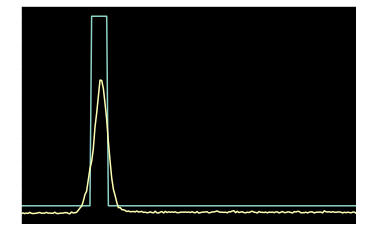

In [6]:
def getVesRel(d, resultPath, resCa=0.2, trials=2000, pools=False):
    RRP = int(getSimInfo(d, 'RRP'))
    CaFile = os.path.join(resultPath, d, f'CaConc_AZ_1.dat')
    tp = np.genfromtxt(CaFile, usecols=(0,1), unpack=True)
    pkid = detect_peaks(tp[1], mph=1, mpd=100, show=False)
    capk = 8#np.mean(tp[1][pkid])
    #print(capk)
    
    CaData = np.full(tp.shape, resCa)
    CaData[0] = tp[0]
    for p in pkid:
        CaData[1][p-5:p+5] = capk
        
    plt.plot(*CaData)
    plt.plot(*tp)
    plt.xlim(0,0.01)
    #plt.ylim(0,0.5)
    #CaData = np.append([tp[0], [], axis=0)        
    #print(sCaData.shape, aCaData.shape)
    
    d = f'resCa_{resCa}_RRP_{RRP}'
    if not os.path.exists(os.path.join(resultPath,d)):
        os.makedirs(os.path.join(resultPath,d))
    np.savetxt(os.path.join(resultPath, d, 'CaConc.dat'), CaData.T, fmt='%0.5f')
    
    #'''
    if pools: p = Pool(pools)
    else: p = Pool()
        
    vesData = {}
    info = product([CaData], [RRP]*trials)
    data = np.array(p.starmap(runAZTrials, info))

    vesSync  = [a['sync'] for a in data[:,0]]
    vesAsync = [a['async'] for a in data[:,0]]
    vesSpont = [a['spont'] for a in data[:,0]]
    vesData.update({f'AZ': {'sync': vesSync, 'async':vesAsync, 'spont':vesSpont}})

    resAZ = data[:,1]
    AZstates = np.mean(resAZ, axis=0)
    fAZ = os.path.join(resultPath, d, f'AZ.dat')
    AZdata = np.hstack((np.array([CaData[0]]).T, AZstates))
    np.savetxt(fAZ, AZdata, fmt=['%0.5f']+['%0.4f']*18, delimiter="\t")
    
    #print(vesData)
    p.close()
    with open(os.path.join(resultPath, d, 'vesData.dat'), "wb") as outfile:
        pk.dump(vesData, outfile)
#'''
#getVesRel(tempdirs[20], resultPath=resultPath, resCa=0.2, trials=30000, pools=35)
getVesRel(dirs[20], resultPath=resultPath, resCa=0.4, trials=30000, pools=35)

In [ ]:
for ttt in  ['a', 's']:
    for d in dirs[:]:
        resultDir = os.path.join(resultPath, d)
        tpoints, avgEPSC = getAvgEPSC(resultDir, ttt+'vesData.dat')
        fepsc = os.path.join(resultPath, d, ttt+'epsc.dat')
        #np.savetxt(fepsc, np.array([tpoints, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")
        #plt.plot(tpoints, avgEPSC)
        
        '''allapTimes = {}
        for APth in range(75, 201, 25):
            apTimes = getAPTimes(resultDir, ttt+'vesData.dat', APth=APth)
            allapTimes.update({APth: apTimes})
        with open(os.path.join(resultPath, d, ttt+'apTimes.dat'), "wb") as outfile:
            pk.dump(allapTimes, outfile)
        print(ttt, d)'''

## AP generation and EPSC calculations

In [92]:
%%time
sigma = 0.2 # noise amplitude
tstep = 0.1 # ms
for d, ttt in product(dirs[:], ['a', 's']):
    resultDir = os.path.join(resultPath, d)
    indices, vesreltimes, nCA3 = getVesInput(resultDir, ttt=ttt, delta=tstep/1000)

    start_scope()
    defaultclock.dt = tstep*ms

    CA3inp = SpikeGeneratorGroup(nCA3, indices, vesreltimes*second)
    #nCA3 = 4; CA3inp = SpikeGeneratorGroup(nCA3, indices[:35], vesreltimes[:35]*second)

    ## CA3 neuron
    V_L = -60.0*mV
    V_thr = -42.0*mV
    V_reset = -65.0*mV

    Cm = 0.025*nF # membrane capacitance
    gm = 0.5*nS  # membrane leak
    tau_rp = 5.0*ms # refractory period 

    gmax_ampa = 1*nsiemens # max AMPA conductance
    tau_g_ampa = 10*ms
    tau_d = 50*ms # desensitisation
    
    tau_nt = 1*ms
    
    A1, A2 = 5/(mM*ms), 0.18/ms
    g_gabaA = 1*nsiemens
    V_gabaA = -85*mV

    B1, B2 = 0.09/(mM*ms), 0.0012/ms
    K1, K2 = 0.18/ms, 0.034/ms
    g_gabaB = 3*nsiemens
    V_gabaB = -95*mV


    eqnCA3 = '''
    dv/dt = (- gm*(v - V_L) - I_ampa - I_gabaA - I_gabaB) / Cm : volt (unless refractory)
    I_ampa = gmax_ampa*g_ampa*d*v : amp
    dg_ampa/dt = -g_ampa/tau_g_ampa : 1
    dd/dt = (1-d)/tau_d : 1

    I_gabaA = g_gabaA*f_gabaA*(v - V_gabaA): amp
    df_gabaA/dt = A1*nt*(1 - f_gabaA) - A2*f_gabaA : 1

    I_gabaB = g_gabaB * G**4/(G**4+100)*(v - V_gabaB): amp
    df_gabaB/dt = B1*nt*(1 - f_gabaB) - B2*f_gabaB : 1
    dG/dt = K1*f_gabaB - K2*G: 1

    nt : mM
    '''

    CA3 = NeuronGroup(nCA3, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                      refractory=tau_rp, method='euler')
    CA3.v = V_L
    CA3.d = 1
    
    ## DG input spikes for interneurons
    simInfo = getSimInfo(d)
    ISI, nAP = int(simInfo['ISI']), int(simInfo['nAP'])
    try: bISI, nB = int(simInfo['bISI']), int(simInfo['nB'])
    except KeyError: bISI, nB = 0, 1
    stimTimes = np.sort([1.5 + na*ISI + nb*bISI for na,nb in product(range(nAP), range(nB))])/1000
    sptimes = np.array(stimTimes)*second
    
    DG = SpikeGeneratorGroup(1, np.zeros(sptimes.shape), sptimes)
    
    ## Inhibitory Interneuron
    Cm_in = 0.1*nF # membrane capacitance
    gm_in = 4.0*nS # membrane leak
    tau_rp_in = 1*ms # refractory period
    Vin_rest = -57.0*mV
    Vin_thr, Vin_reset = -50.0*mV, -60.0*mV
    gInmax_ampa = 5*nS
    tau_gIn_ampa = 2*ms

    eqnIn = '''
    dv/dt = (- gm_in*(v - Vin_rest) - I_ampa)/Cm_in + sigma*sqrt(1/(1*ms))*xi*mV: volt (unless refractory)
    I_ampa = gInmax_ampa*gIn_ampa*v : amp
    dgIn_ampa/dt = -gIn_ampa/tau_gIn_ampa : 1
    '''
    
    nIn = 1000
    In = NeuronGroup(nIn, eqnIn, threshold='v > Vin_thr', reset='v = Vin_reset',
                       refractory=tau_rp_in, method='euler')
    In.v = '-60*mV + rand()*10*mV'
    
    ### Synapses
    on_preCA3 = 'g_ampa += 1; d -= 0*d'
    S_CA3inp_CA3 = Synapses(CA3inp, CA3, on_pre=on_preCA3)
    S_CA3inp_CA3.connect('i==j')
    
    on_preIn = 'gIn_ampa += 1'
    S_DG_In = Synapses(DG, In, delay=0.1*ms, on_pre=on_preIn)
    S_DG_In.connect(i=0, j=range(nIn))
    
    ## In ---> CA3 synapse
    eqnSIn = '''
    dnT/dt = -nT/tau_nt: mM (clock-driven)
    nt_post = nT : mM (summed) '''
    
    kk = 10 # average number of inputs a CA3 neuron receives
    S_In_CA3 = Synapses(In, CA3, model=eqnSIn, method='euler', delay=0.1*ms, on_pre='nT += 0.5*mM')
    S_In_CA3.connect(p=kk/nIn)
    
    ### Monitors
    stMCA3 = StateMonitor(CA3, variables=True, record=True)
    spMCA3 = SpikeMonitor(CA3)
    
    spMinp = SpikeMonitor(CA3inp)
    
    stMIn = StateMonitor(In, variables=True, record=True)
    spMIn = SpikeMonitor(In)

    spMDG = SpikeMonitor(DG)
    
    stMS = StateMonitor(S_In_CA3, variables=True, record=True)

    runt = 210 # ms
    run(runt*ms)
    
    avgEPSC = -np.mean((stMCA3.I_ampa + stMCA3.I_gabaA + stMCA3.I_gabaB)/pamp, axis=0)
    fepsc = os.path.join(resultDir, ttt+'epsc.dat')
    np.savetxt(fepsc, np.array([stMCA3.t/second, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")

    apTimes = [a/second for a in list(spMCA3.spike_trains().values())]
    with open(os.path.join(resultDir, ttt+'apTimes.dat'), "wb") as outfile:
        pk.dump(apTimes, outfile)

CPU times: user 10min 34s, sys: 57.1 s, total: 11min 31s
Wall time: 11min 31s


CPU times: user 497 ms, sys: 79.9 ms, total: 577 ms
Wall time: 575 ms


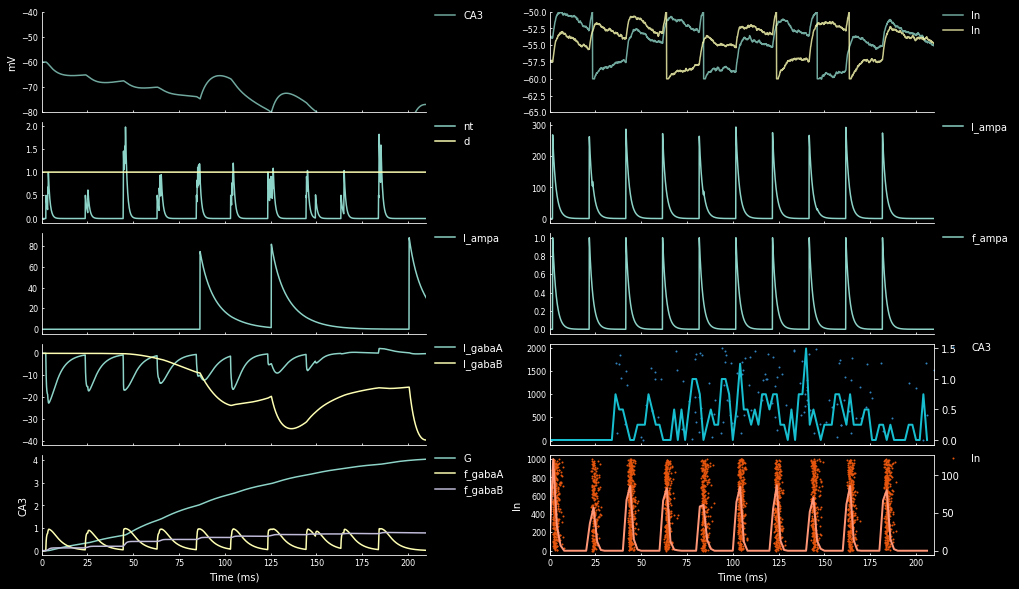

In [93]:
%%time
f, ax = plt.subplots(5, 2, sharex=True, figsize=(16,10))
f.subplots_adjust(wspace=0.32, hspace=0.1)
ax31t, ax41t = ax[3,1].twinx(), ax[4,1].twinx()
axt = [ax31t, ax41t]

ax[0,0].plot(stMCA3.t/ms, stMCA3.v[:1].T/mV, alpha=0.8, label='CA3')
ax[0,0].set_ylabel('mV')
ax[0,0].set_ylim(-80,-40)

ax[1,0].plot(stMCA3.t/ms, stMCA3.nt[:1].T, label='nt')
ax[1,0].plot(stMCA3.t/ms, stMCA3.d[:1].T, label='d')

ax[2,0].plot(stMCA3.t/ms, -stMCA3.I_ampa[:1].T/pamp, label='I_ampa')
ax[3,0].plot(stMCA3.t/ms, -stMCA3.I_gabaA[:1].T/pamp, label='I_gabaA')
ax[3,0].plot(stMCA3.t/ms, -stMCA3.I_gabaB[:1].T/pamp, label='I_gabaB')

ax[4,0].plot(stMCA3.t/ms, stMCA3.G[:1].T, label='G')
ax[4,0].plot(stMCA3.t/ms, stMCA3.f_gabaA[:1].T, label='f_gabaA')
ax[4,0].plot(stMCA3.t/ms, stMCA3.f_gabaB[:1].T, label='f_gabaB')

apratet, aprate = getSpikeRate(spMCA3, nCA3, runt=runt, bindt=2)
ax[3,1].plot(spMCA3.t/ms, spMCA3.i, '.', color=cppaired[0], ms=2, label='CA3')
ax31t.plot(apratet, aprate, color=cppaired[1], lw=2)
ax[4,0].set_ylabel('CA3')

ax[0,1].plot(stMIn.t/ms, stMIn.v[:2].T/mV, alpha=0.8, label='In')
ax[0,1].set_ylim(-65,-50)

ax[1,1].plot(stMIn.t/ms, -stMIn.I_ampa[:1].T/pamp, label='I_ampa')

ax[2,1].plot(stMIn.t/ms, stMIn.gIn_ampa[:1].T, label='f_ampa')

apratet, aprate = getSpikeRate(spMIn, nIn, runt=runt, bindt=2)
ax[4,1].plot(spMIn.t/ms, spMIn.i, '.', color=cppaired[2], ms=2, label='In')
ax41t.plot(apratet, aprate, color=cppaired[3], lw=2)
ax[4,1].set_ylabel('In')

[axis.set_xlabel('Time (ms)') for axis in ax[-1,:]]
for axis in list(ax.ravel()):# + axt:
    axis.set_xlim(0, runt)
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)
    axis.legend(frameon=False, bbox_to_anchor=(1.0, 0.9, 0.3, 0.2), loc='upper left')

In [94]:
sp = [(a/ms).tolist() for a in list(spMIn.spike_trains().values())]
nsp = [len(a) for a in sp]
np.mean(nsp)

3.047

## [OLD] AP generation and EPSC calculations 

In [24]:
for ttt in  ['a']:#, 's']:
    for d in dirs[:]:
        resultDir = os.path.join(resultPath, d)
        EPSC, tstep = getAllEPSC(resultDir, ttt=ttt)
        N = EPSC.shape[0]
        
        ### Run Brian simulations
        start_scope()
        ## set clock dt to data dt
        defaultclock.dt = tstep*second

        ### AMPA conductance
        gAMPA = TimedArray(EPSC.T*psiemens*20, dt=defaultclock.dt)

        # voltage
        V_L = -60.0*mV
        V_thr = -42.0*mV
        V_reset = -65.0*mV
        V_E = 0.0*mV

        Cm = 0.025*nF # membrane capacitance
        gm = 0.5*nS  # membrane leak
        tau_rp = 5.0*ms # refractory period

        eqnCA3 = '''
        dv/dt = (- gm*(v - V_L) - I_AMPA) / Cm : volt (unless refractory)
        I_AMPA = gAMPA(t,i)*v : amp '''
        
        CA3 = NeuronGroup(N, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                          refractory=tau_rp, method='euler')
        CA3.v = V_L

        stM = StateMonitor(CA3, variables=True, record=True)
        spM = SpikeMonitor(CA3)

        runt = 510*ms
        run(runt)
        
        avgEPSC = -np.mean(stM.I_AMPA/pamp, axis=0)

        fepsc = os.path.join(resultDir, ttt+'epsc.dat')
        np.savetxt(fepsc, np.array([stM.t/second, avgEPSC]).T, fmt=['%0.5f']+['%0.2f'], delimiter="\t")
        
        apTimes = [a/second for a in list(spM.spike_trains().values())]
        with open(os.path.join(resultDir, ttt+'apTimes.dat'), "wb") as outfile:
            pk.dump(apTimes, outfile)

WARNING    "i" is an internal variable of group "neurongroup_1", but also exists in the run namespace with the value 9. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


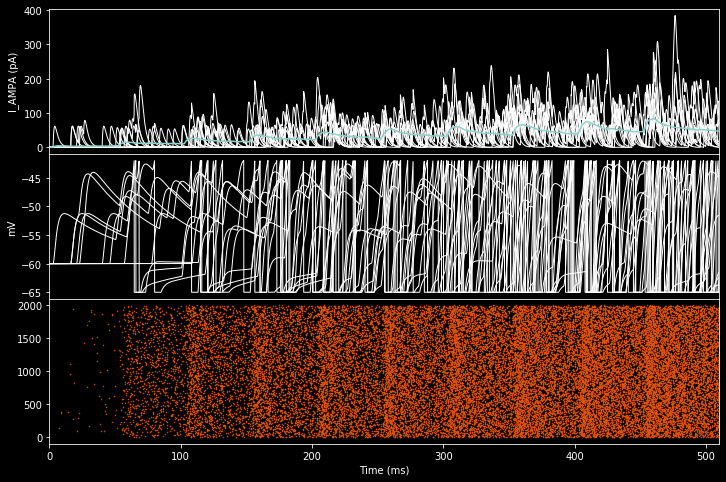

In [25]:
f, ax = plt.subplots(3, sharex=True, figsize=(12,8))
f.subplots_adjust(wspace=0., hspace=0.)
lw = 1

for i in range(10):
    ax[0].plot(stM.t/ms, -stM.I_AMPA[i]/pamp, color=cpall[-1], lw=lw, label='I_AMPA')
    ax[1].plot(stM.t/ms, stM.v[i]/mV, color=cpall[-1], lw=lw, label='v')
ax[0].plot(stM.t/ms, avgEPSC, label='I_AMPA')
ax[0].set_ylabel('I_AMPA (pA)')
ax[1].set_ylabel('mV')
ax[0].set_xlim(0,runt/ms)
#ax[0].legend()

ax[2].plot(spM.t/ms, spM.i, '.k', color=cpall[2], ms=1)
ax[2].set_xlabel('Time (ms)');

# Information Theoretic Analysis

/home/nishant/.local/lib/python3.6/site-packages/ipykernel_launcher.py:35: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray


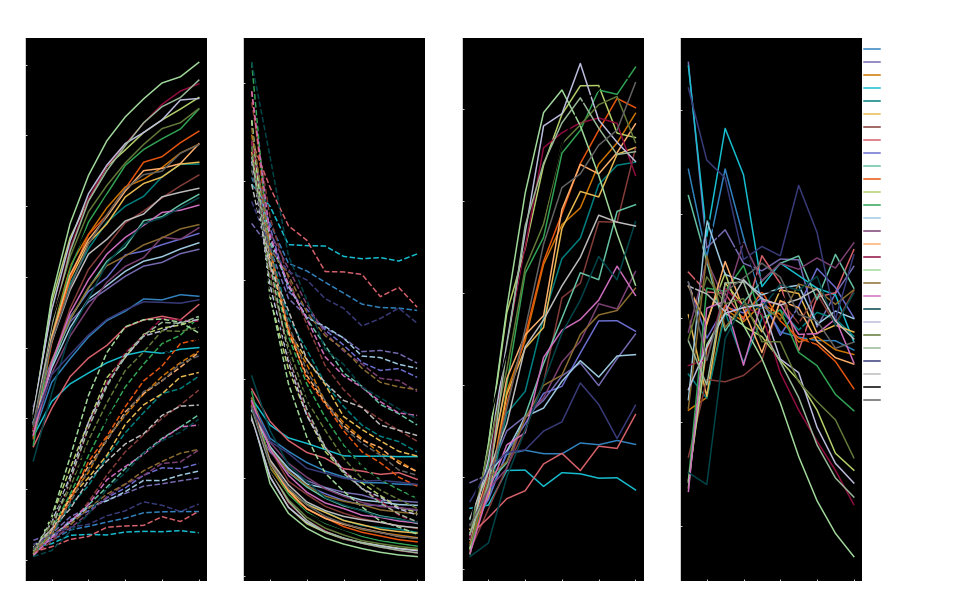

In [139]:
APth = 100
d = dirs[17]
f, ax = plt.subplots(1, 4, sharex=True, figsize=(15,10))
f.subplots_adjust(wspace=0.2, hspace=0.0)

for c,d in enumerate(dirs[:28]):
    label = str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1]
    nAP = int(getSimInfo(d, 'nAP'))

    ### Get vesicle release times for each trial
    inf = os.path.join(resultPath, d, 'avesData.dat')
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)
    df = pd.io.json.json_normalize(vesData, sep='_')    
    df = df.to_dict(orient='records')[0]
    seeds = len(df['AZ1_sync'])
    emptyKeys = []
    for k,v in df.items():
        if all([not a for a in v]):
            emptyKeys.append(k)
    for e in emptyKeys:
        df.pop(e)
    vrel = [[] for _ in range(seeds)]
    for vs in df.values():
        for i,v in enumerate(vs):
            vrel[i] += v
    for i,vr in enumerate(vrel):
        vrel[i] = np.sort(vr)#.tolist()

    ### get AP times
    inf = os.path.join(resultPath, d, 'aapTimes.dat')
    with open(inf, "rb") as infile:
        apTimes = pk.load(infile)
        seeds = len(apTimes[APth])
    apts = np.array(apTimes[APth])
    #print(apts.shape)

    ### Summarise nRel and nAP data 
    # [nRel, nAP_gen] for each incoming AP and seed
    info = np.zeros((seeds, nAP, 2), dtype=int)
    ts,  tc = 0.002, 0.02

    for i in range(seeds):
        inrel = [int(np.floor(a)) for a in (vrel[i]-ts)/tc]
        nrel = [inrel.count(n) for n in range(nAP)]

        inap_gen = [int(np.floor(a)) for a in (np.array(apts[i])-ts)/tc]
        nap_gen = [inap_gen.count(n) for n in range(nAP)]
        #print(nrel, '\n', nap_gen)

        info[i,:,:] = np.array(list([nrel, nap_gen]), dtype=int).T

    avgq = np.sum(info, axis=0)/seeds # no. of nrel and nap_gen for each incoming AP averaged over seeds

    ### nth state refers to n amount of quantity (rel or AP)
    ### Calculate Pr for each state: Prel, Pap
    m = [int(a)+1 for a in np.max(info, axis=(0,1))] # number of states
    Prel = np.zeros((nAP, m[0]))
    Pap = np.zeros((nAP, m[1]))
    #print(Prel.shape, Pap.shape)

    for nap in range(nAP):
        unique, counts = np.unique(info[:,nap,0], return_counts=True)
        #print(nap, unique, counts)
        for i, unq in enumerate(unique):
            Prel[nap, unq] = counts[i]

        unique, counts = np.unique(info[:,nap,1], return_counts=True)
        #print(nap, unique, counts)
        for i, unq in enumerate(unique):
            Pap[nap, unq] = counts[i]

    Prel = Prel/seeds
    Pap = Pap/seeds
    #Pap[0]

    ### Joint Probability distribution P(nRel U nAP_gen)
    m = [int(a)+1 for a in np.max(info, axis=(0,1))] # number of states
    jointP = np.zeros((nAP, *m)) # nRel, nAP_gen
    for i in range(info.shape[0]):
        for nap in range(info.shape[1]):
            jointP[nap, info[i][nap][0], info[i][nap][1]] += 1
    jointP = jointP/seeds
    #print(jointP[7])

    with np.errstate(divide='ignore'):
        Hap = np.sum(Pap*np.ma.log2(1/Pap).filled(0), axis=1)
        Hrel = np.sum(Prel*np.ma.log2(1/Prel).filled(0), axis=1)
        Hjoint = np.sum(jointP*np.ma.log2(1/jointP).filled(0), axis=(1,2))
    MI = Hap + Hrel - Hjoint

    APs = range(1, nAP+1)
    ax[0].plot(APs, Hrel, '-', c=cpall[c%28], label='Rel')
    ax[0].plot(APs, Hap, '--', c=cpall[c%28], label='AP')
    ax[0].set_title('Entropy')
    ax[0].set_xlabel('Stimulus number')

    ax[1].plot(APs, Hrel/avgq[:,0], '-', c=cpall[c%28], label='EN_Rel')
    ax[1].plot(APs, Hap/avgq[:,1], '--', c=cpall[c%28], label='EN_AP')
    ax[1].set_title('Energy normalised\nentropy')
    ax[1].set_xlabel('Stimulus number')

    #ax[2].plot(APs, Hjoint, 'o-', label='Hjoint')
    ax[2].plot(APs, MI, '-', c=cpall[c%28], label=label)
    ax[2].set_title('Mutual Information')
    ax[2].set_xlabel('Stimulus number')
    
    ax[3].plot(APs, MI/avgq[:,0], '-', c=cpall[c%28], label=label)
    ax[3].set_title('Energy normalised\nMutual Information')
    ax[3].set_xlabel('Stimulus number')
    ax[3].legend(frameon=False, ncol=1, handlelength=2, fontsize=8,
                 loc='upper right', bbox_to_anchor=(1.5, 1.0))
    
for axis in ax.ravel():
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=9)

## Extra Stuff

### Vesicle release as spike input

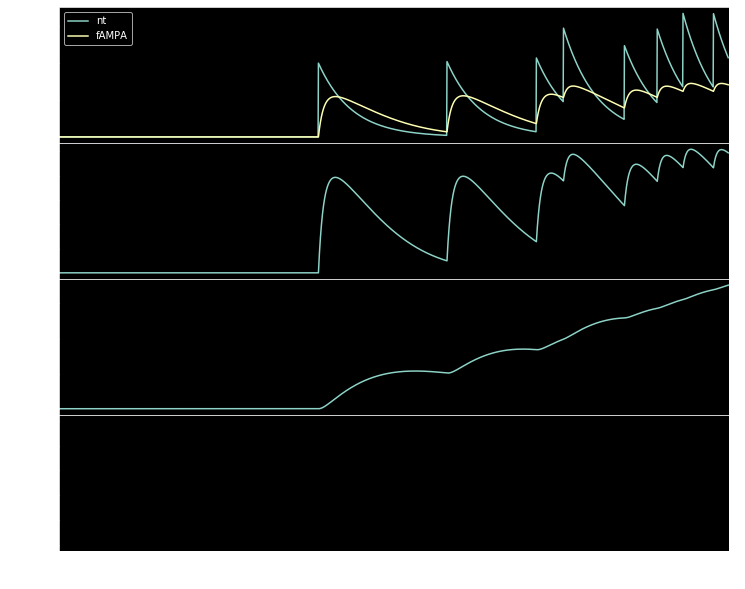

In [34]:
### Setting DG transmitter release times as spike inputs
APth = 100
inf = os.path.join(resultPath, dirs[17], 'aapTimes.dat')
with open(inf, "rb") as infile:
    apTimes = pk.load(infile)
    N = len(apTimes[APth])
    
nn = 1
indices, times = [], []
for n,apt in enumerate(apTimes[APth][:nn]):
    indices += [n for _ in range(len(apt))]
    times += apt
times = np.array(times)*second
indices = np.array(indices)

DGsp = SpikeGeneratorGroup(nn, indices, times)

# voltage
V_L = -60. * mV
V_thr = -50. * mV
V_reset = -65. * mV
V_E = 0. * mV

# membrane capacitance
C_m_E = 10 * nF

# membrane leak
g_m_E = 2*1e2 * nS

# refractory period
tau_rp_E = 5.0*ms

# AMPA (excitatory)
g_AMPA = 1.2e-2*mS
tau_nt = 10.0*ms
a = 0.4/ms
b = 0.2/ms

eqnCA3 = '''
dv/dt = (- g_m_E*(v - V_L) - I_syn) / C_m_E : volt (unless refractory)
I_syn = I_AMPA : amp

dnt/dt = -nt/tau_nt : 1
I_AMPA = g_AMPA*f_AMPA*v*1e-3 : amp
df_AMPA/dt = a*nt*(1 - f_AMPA) - b*f_AMPA : 1
'''

eqnS = '''
dnt/dt = -nt/tau_nt : 1 (clock-driven)
'''

CA3 = NeuronGroup(nn, eqnCA3, threshold='v > V_thr', reset='v = V_reset', 
                  refractory=tau_rp_E, method='euler')
CA3.v = V_L


#C_E_E = Synapses(DGsp, CA3, model=eqnS, on_pre='s_AMPA += w', method='euler')
C_E_E = Synapses(DGsp, CA3, on_pre='nt += 1', method='euler')
C_E_E.connect('i == j')

stM = StateMonitor(CA3, variables=True, record=True)
spM = SpikeMonitor(CA3)

runt = 200*ms
run(runt)

f, ax = plt.subplots(4, sharex=True, figsize=(12,10))
f.subplots_adjust(wspace=0., hspace=0.)

for i in range(1):
    ax[0].plot(stM.t/ms, stM.nt[i], label='nt')
    ax[0].plot(stM.t/ms, stM.f_AMPA[i], label='fAMPA')
    ax[1].plot(stM.t/ms, -stM.I_syn[i]/pamp, label='I_syn')
    ax[2].plot(stM.t/ms, stM.v[i]/mV, label='v')
ax[0].set_ylabel('Frac')
ax[1].set_ylabel('I_AMPA (pA)')
ax[2].set_ylabel('mV')
ax[0].set_xlim(0,runt/ms)
ax[0].legend()

ax[3].plot(spM.t/ms, spM.i, '.k', color=cpall[2], ms=1)
ax[3].set_xlabel('Time (ms)');